# Hand pose reconstruction from global quaternions

This notebook reconstructs a simple hand skeleton from IMU orientations given as **global/world-frame quaternions** for the palm, proximal phalanx, and middle phalanx.  
It computes segment orientations, relative joint rotations, and fingertip positions using forward kinematics.

## Assumptions

- Each quaternion gives the orientation of the segment frame in the world frame.
- Each finger is modeled as a kinematic chain: palm -> proximal -> middle -> distal/tip.
- Bone lengths are known.
- The local finger axis is chosen along +X.
- A fixed sensor-to-segment alignment can be inserted if your IMUs are not mounted in the segment frame.

## Important relation

If \(R_	ext{prox}\) and \(R_	ext{mid}\) are both in the world frame, then the relative rotation from proximal to middle is:

\[
R_{	ext{prox} 	o 	ext{mid}} = R_	ext{prox}^T R_	ext{mid}
\]

Do **not** subtract rotation matrices.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def normalize_quaternion(q):
    q = np.asarray(q, dtype=float)
    return q / np.linalg.norm(q)


def quat_to_rotmat(q, order='wxyz'):
    q = normalize_quaternion(q)
    if order == 'wxyz':
        w, x, y, z = q
    elif order == 'xyzw':
        x, y, z, w = q
    else:
        raise ValueError("order must be 'wxyz' or 'xyzw'")

    R = np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)]
    ])
    return R


def make_transform(R, t):
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = np.asarray(t, dtype=float)
    return T


def transform_point(T, p):
    p_h = np.append(np.asarray(p, dtype=float), 1.0)
    return (T @ p_h)[:3]

In [3]:
def relative_rotation(R_parent, R_child):
    return R_parent.T @ R_child


def fk_finger_from_global_rotations(
    R_palm,
    R_prox,
    R_mid,
    palm_to_mcp,
    L_prox,
    L_mid,
    L_dist,
    distal_mode='inherit_mid'
):
    palm_origin = np.zeros(3)
    mcp = palm_origin + R_palm @ np.asarray(palm_to_mcp, dtype=float)
    pip = mcp + R_prox @ np.array([L_prox, 0.0, 0.0])
    dip = pip + R_mid @ np.array([L_mid, 0.0, 0.0])

    if distal_mode == 'inherit_mid':
        R_dist = R_mid
    else:
        R_dist = R_mid

    tip = dip + R_dist @ np.array([L_dist, 0.0, 0.0])

    return {
        'palm_origin': palm_origin,
        'mcp': mcp,
        'pip': pip,
        'dip': dip,
        'tip': tip,
        'R_rel_prox_to_mid': relative_rotation(R_prox, R_mid)
    }

In [4]:
# Example input data
# Replace these with your actual IMU quaternions.
# Convention here: [w, x, y, z]

example = {
    'palm_q': [1.0, 0.0, 0.0, 0.0],
    'prox_q': [0.9962, 0.0, 0.0872, 0.0],
    'mid_q':  [0.9848, 0.0, 0.1736, 0.0]
}

R_palm = quat_to_rotmat(example['palm_q'])
R_prox = quat_to_rotmat(example['prox_q'])
R_mid  = quat_to_rotmat(example['mid_q'])

# Example geometry in meters
palm_to_mcp = np.array([0.06, 0.02, 0.0])
L_prox = 0.045
L_mid  = 0.025
L_dist = 0.020

result = fk_finger_from_global_rotations(
    R_palm, R_prox, R_mid,
    palm_to_mcp,
    L_prox, L_mid, L_dist
)

result

{'palm_origin': array([0., 0., 0.]),
 'mcp': array([0.06, 0.02, 0.  ]),
 'pip': array([ 0.10431567,  0.02      , -0.00781803]),
 'dip': array([ 0.12780877,  0.02      , -0.01636637]),
 'tip': array([ 0.14660325,  0.02      , -0.02320504]),
 'R_rel_prox_to_mid': array([[ 0.9848389 ,  0.        ,  0.17347145],
        [ 0.        ,  1.        ,  0.        ],
        [-0.17347145,  0.        ,  0.9848389 ]])}

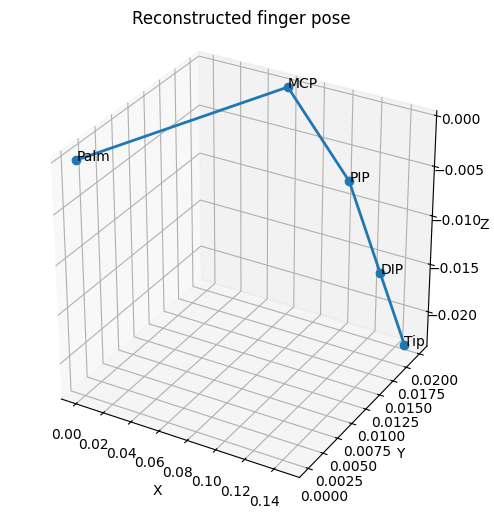

In [5]:
points = np.vstack([
    result['palm_origin'],
    result['mcp'],
    result['pip'],
    result['dip'],
    result['tip']
])
labels = ['Palm', 'MCP', 'PIP', 'DIP', 'Tip']

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(points[:, 0], points[:, 1], points[:, 2], '-o', linewidth=2)

for p, label in zip(points, labels):
    ax.text(p[0], p[1], p[2], label)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Reconstructed finger pose')
ax.set_box_aspect([1, 1, 1])
plt.show()

## Using your own data

Replace the example quaternions with your measured values.

If you have sensor misalignment, insert a fixed rotation:

```python
R_segment = R_sensor @ R_align
```

or

```python
R_segment = R_align @ R_sensor
```

depending on your frame convention.

Be consistent about whether your quaternion represents:

- segment in world, or
- world in segment.

If your finger link direction is not along local +X, change the translation vectors accordingly.

In [6]:
# Optional: batch processing from a CSV file
# Expected columns example:
# palm_w,palm_x,palm_y,palm_z,prox_w,prox_x,prox_y,prox_z,mid_w,mid_x,mid_y,mid_z

# df = pd.read_csv('your_file.csv')
# tips = []
# for _, row in df.iterrows():
#     R_palm = quat_to_rotmat([row.palm_w, row.palm_x, row.palm_y, row.palm_z])
#     R_prox = quat_to_rotmat([row.prox_w, row.prox_x, row.prox_y, row.prox_z])
#     R_mid  = quat_to_rotmat([row.mid_w,  row.mid_x,  row.mid_y,  row.mid_z])
#
#     result = fk_finger_from_global_rotations(
#         R_palm, R_prox, R_mid,
#         palm_to_mcp,
#         L_prox, L_mid, L_dist
#     )
#     tips.append(result['tip'])
#
# tips = np.array(tips)
# pd.DataFrame(tips, columns=['tip_x', 'tip_y', 'tip_z']).to_csv('fingertips.csv', index=False)